In [3]:
import pyarrow.parquet as pq
import pandas as pd

path = "/Users/pablom.perez/Desktop/data/legacysurvey_hsc_crossmatched/train.parquet"

pf = pq.ParquetFile(path)

# Read only first 100 rows
batch = next(pf.iter_batches(batch_size=100))
df = batch.to_pandas()

print(df.shape)

(100, 70)


In [5]:
df.keys()

Index(['z_cmodel_mag', 'z_sdssshape_shape12', 'a_g', 'a_r',
       'y_sdssshape_psf_shape11', 'FLUX_R', 'FLUX_W3', 'i_cmodel_mag',
       'z_sdssshape_shape22', 'legacysurvey_object_id', 'hsc_object_id',
       'r_sdssshape_psf_shape11', 'legacysurvey_image', 'hsc_image',
       'z_extendedness_value', 'r_cmodel_mag', 'i_sdssshape_shape11',
       'i_sdssshape_shape12', 'y_sdssshape_psf_shape12', 'catalog',
       'g_sdssshape_shape11', 'a_i', 'y_cmodel_mag', 'rgb',
       'g_sdssshape_psf_shape11', 'g_sdssshape_shape12',
       'y_sdssshape_psf_shape22', 'y_sdssshape_shape11', 'a_y',
       'i_sdssshape_psf_shape12', 'g_sdssshape_shape22', 'object_mask',
       'i_sdssshape_psf_shape11', 'r_sdssshape_psf_shape22', 'FLUX_W1', 'a_z',
       'g_cmodel_mag', 'g_sdssshape_psf_shape12', 'SHAPE_E1',
       'r_sdssshape_psf_shape12', 'EBV', 'g_extendedness_value',
       'r_sdssshape_shape11', 'FLUX_I', 'i_sdssshape_shape22',
       'y_sdssshape_shape22', 'blobmodel', 'y_extendedness_value',


In [27]:
hsc_images = df['hsc_image']
hsc = hsc_images[0]['flux']

In [36]:
import numpy as np

x = np.stack([np.stack(a, axis=0) for a in hsc], axis=0).astype(np.float32)
print(x.shape, x.dtype)   # (5, 160, 160) float32
hsc=x

(5, 160, 160) float32


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18391296..3.613803].


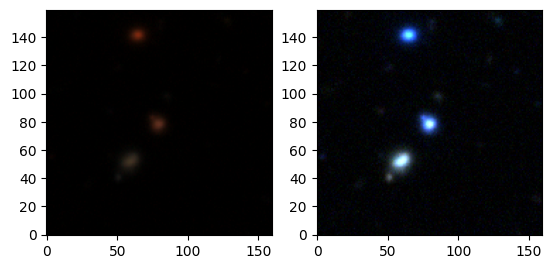

In [40]:
import matplotlib.pyplot as plt
import torch

hsc=torch.tensor(x)
from astropy.visualization import make_lupton_rgb
rgb = make_lupton_rgb(hsc[2], hsc[1], hsc[0],)
fig, ax = plt.subplots(1, 2)
ax[0].imshow(rgb, origin='lower')
ax[1].imshow(hsc[:3].permute(1, 2, 0), origin='lower')